# RoBERTa Sentiment Classification
Fine-tuning RoBERTa-base on SST-5 dataset.

In [ ]:
#Import libraries
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import numpy as np

In [ ]:
#Config
batch_size = 16
max_length = 128
num_epochs = 3
learning_rate = 2e-5
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
#Load SST-5 dataset
dataset = load_dataset('SetFit/sst5')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
#Load tokenizer and tokenize dataset
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
def tokenize(example):
    return tokenizer(example['text'], padding='max_length', truncation=True, max_length=max_length)
dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1101 [00:00<?, ? examples/s]

In [ ]:
#Load model
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=5)
model.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epochs,
    learning_rate=learning_rate,
    eval_strategy='epoch'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test']
)

In [ ]:
#Train the model
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.205480,0.999481
2,0.948379,1.027610
3,0.796928,1.014018


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1602, training_loss=0.9692431865411156, metrics={'train_runtime': 690.4752, 'train_samples_per_second': 37.122, 'train_steps_per_second': 2.32, 'total_flos': 1686061056909312.0, 'train_loss': 0.9692431865411156, 'epoch': 3.0})

In [ ]:
#Prediction function with label mapping

labels = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']

def predict(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs).item()
    return labels[pred]

In [ ]:
#Demo examples
examples = [
    "This is the worst thing ever",
    "It wasn't good",
    "It was okay, nothing special",
    "I liked it quite a bit",
    "Absolutely fantastic experience"
]

for text in examples:
    print(text, '->', predict(text))

This is the worst thing ever -> Very Negative
It was bad -> Very Negative
It was okay, nothing special -> Neutral
I liked it quite a bit -> Positive
Absolutely fantastic experience -> Very Positive


In [ ]:
#User input prediction
text = input('Enter a sentence: ')
print('Prediction:', predict(text))

Enter a sentence: It was amazing
Prediction: Very Positive


In [ ]:
#Autocomplete-like suggestions using masked token prediction

from transformers import pipeline

fill_mask = pipeline("fill-mask", model="roberta-base")

def suggest_words(text, top_k=5):
    if "<mask>" not in text:
        print("Please include <mask> in your sentence.")
        return

    results = fill_mask(text, top_k=top_k)

    print(f"\nInput: {text}")
    print("Suggestions:")

    for r in results:
        word = r['token_str'].strip()
        score = round(r['score'], 4)
        print(f"{word} (confidence: {score})")

#Example usage
suggest_words("The movie was <mask>.")
suggest_words("This experience felt <mask> and strange.")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Input: The movie was <mask>.
Suggestions:
good (confidence: 0.1075)
awful (confidence: 0.0763)
great (confidence: 0.0714)
terrible (confidence: 0.0682)
released (confidence: 0.0271)

Input: This experience felt <mask> and strange.
Suggestions:
foreign (confidence: 0.109)
strange (confidence: 0.0694)
unfamiliar (confidence: 0.0529)
surreal (confidence: 0.0513)
unexpected (confidence: 0.0502)


In [ ]:
#Evaluation Metrics: Accuracy, Precision, Recall, F1

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

#Get predictions from trainer
predictions = trainer.predict(dataset['test'])

#Convert logits to predicted class
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

#Metrics
accuracy = accuracy_score(labels, preds)
precision = precision_score(labels, preds, average='macro')
recall = recall_score(labels, preds, average='macro')
f1 = f1_score(labels, preds, average='macro')

print("===== Evaluation Metrics =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

#Detailed report
label_names = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']
print("\n===== Classification Report =====")
print(classification_report(labels, preds, target_names=label_names))

===== Evaluation Metrics =====
Accuracy  : 0.5706
Precision : 0.5591
Recall    : 0.5549
F1 Score  : 0.5548

===== Classification Report =====
               precision    recall  f1-score   support

Very Negative       0.56      0.51      0.53       279
     Negative       0.60      0.63      0.62       633
      Neutral       0.43      0.33      0.37       389
     Positive       0.56      0.63      0.59       510
Very Positive       0.65      0.68      0.67       399

     accuracy                           0.57      2210
    macro avg       0.56      0.55      0.55      2210
 weighted avg       0.56      0.57      0.57      2210



===== Confusion Matrix =====
          Very Neg  Neg  Neutral  Pos  Very Pos
Very Neg       141  124       10    3         1
Neg             93  400      108   26         6
Neutral         16  130      127  107         9
Pos              2   12       46  322       128
Very Pos         0    0        7  121       271


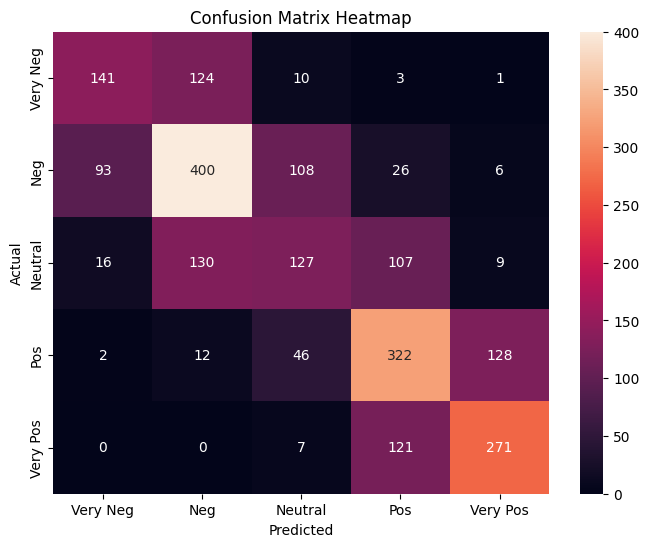

In [ ]:
#Confusion Matrix + Heatmap

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#Compute confusion matrix
cm = confusion_matrix(labels, preds)

label_names = ['Very Neg', 'Neg', 'Neutral', 'Pos', 'Very Pos']

#Convert to DataFrame for better display
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)

print("===== Confusion Matrix =====")
print(cm_df)

#Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()